Data Shape: (6131, 945)
    release_year  duration_minutes  rating_74 min  rating_84 min  rating_G  \
0           2020              90.0          False          False     False   
6           2021              91.0          False          False     False   
7           1993             125.0          False          False     False   
9           2021             104.0          False          False     False   
12          2021             127.0          False          False     False   

    rating_NC-17  rating_NR  rating_PG  rating_PG-13  rating_R  ...  \
0          False      False      False          True     False  ...   
6          False      False       True         False     False  ...   
7          False      False      False         False     False  ...   
9          False      False      False          True     False  ...   
12         False      False      False         False     False  ...   

    listed_in_Movies  listed_in_Music & Musicals  \
0              False        

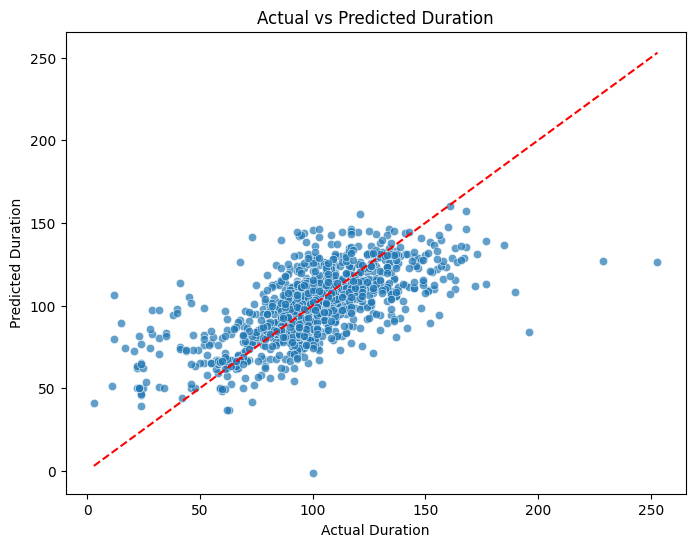

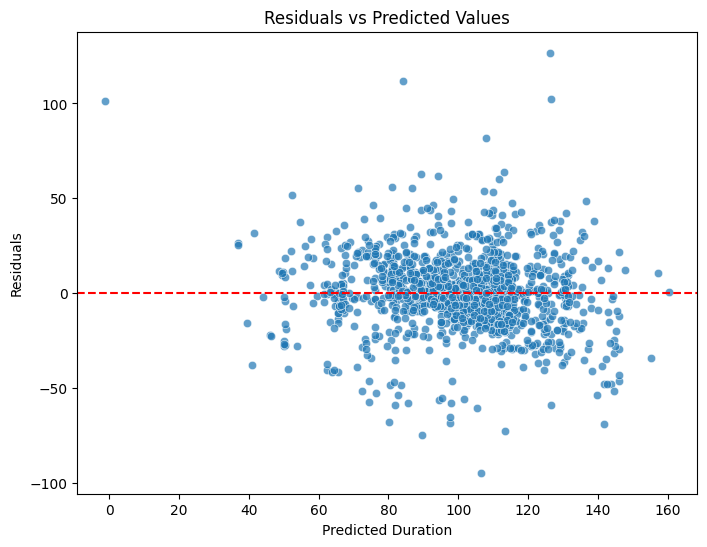

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# =============================
# LOAD NETFLIX DATASET
# =============================
df = pd.read_csv("netflix_titles.csv")

# Same cleaning step style
df.columns = df.columns.str.strip()

# =============================
# DATA CLEANING (Netflix Version)
# =============================

# Keep only Movies (to make regression numeric)
df = df[df['type'] == 'Movie'].copy()

# Convert duration text → numeric
df['duration_minutes'] = df['duration'].str.extract(r'(\d+)').astype(float)

# Drop non-useful identifiers (similar idea to Country/Year removal)
df_clean = df.drop(['show_id','title','director','cast','date_added','description','duration'], axis=1)

# Handle Missing Values (same style)
df_clean.fillna(df_clean.mode().iloc[0], inplace=True)

# One-Hot Encoding (same style as Status encoding)
df_final = pd.get_dummies(df_clean, columns=['type','rating','country','listed_in'], drop_first=True)

print(f"Data Shape: {df_final.shape}")
print(df_final.head())

# =============================
# DEFINE FEATURES + TARGET
# =============================
X = df_final.drop('duration_minutes', axis=1)
y = df_final['duration_minutes']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =============================
# MULTIPLE REGRESSION MODEL
# =============================
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# =============================
# EVALUATION (SAME OUTPUT STYLE)
# =============================
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): {rmse:.2f} minutes")
print(f"R² Score (Accuracy): {r2:.2f}")

comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(comparison.head())

# =============================
# PLOT 1: Actual vs Predicted
# =============================
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')

plt.xlabel('Actual Duration')
plt.ylabel('Predicted Duration')
plt.title('Actual vs Predicted Duration')
plt.show()

# =============================
# PLOT 2: RESIDUALS
# =============================
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.7)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel('Predicted Duration')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.show()
